In [1]:
import pandas as pd

df = pd.read_csv("Dataset/amz_uk_price_prediction_dataset.csv")

In [2]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               str    
 2   title              str    
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 151.5 MB


In [4]:
df.isnull().sum()

uid                  0
asin                 0
title                0
stars                0
reviews              0
price                0
isBestSeller         0
boughtInLastMonth    0
category             0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
#Part 1: Analyzing Best-Seller Trends Across Product Categories
#Crosstab analysis. 
crosstab_result = pd.crosstab(df['category'], df['isBestSeller'])
crosstab_result

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [10]:
#No podemos responder todavia a la pregunta, por lo que vamos a calcular proporciones. 
best_seller_proportion = crosstab_result.div(crosstab_result.sum(axis=1), axis=0).round(2)
best_seller_proportion

isBestSeller,False,True
category,,
3D Printers,1.00,0.00
3D Printing & Scanning,1.00,0.00
Abrasive & Finishing Products,0.98,0.02
Action Cameras,1.00,0.00
Adapters,0.99,0.01
...,...,...
Wind Instruments,0.97,0.03
Window Treatments,0.98,0.02
Women,0.99,0.01


In [11]:
#Ordenar categorias para identificar la mayor proporcion de True (donde best seller es mas comun) y damos respuesta a la pregunta 
best_seller_proportion.sort_values(by=True, ascending=False)

isBestSeller,False,True
category,,
Smart Home Security & Lighting,0.94,0.06
Health & Personal Care,0.94,0.06
Grocery,0.94,0.06
Power & Hand Tools,0.96,0.04
Mobile Phone Accessories,0.96,0.04
...,...,...
Ballet & Dancing Footwear,1.00,0.00
3D Printing & Scanning,1.00,0.00
Baby & Toddler Toys,1.00,0.00


In [ ]:
#Are there categories where being a best-seller is more prevalent?
#Aunque algunas categorías tienen mayor proporción, los valores siguen siendo bastante bajos (alrededor de 4%-6%).
#Eso significa que los best sellers representan una pequeña parte del total de productos en casi todas las categorías.

In [13]:
#Chi-square test
from scipy.stats import chi2_contingency
# Chi-square test for 'category' and 'isBestSeller'
chi2_statistic, chi2_p_value, _, _ = chi2_contingency(crosstab_result)

chi2_statistic, chi2_p_value

(np.float64(36540.20270061387), np.float64(0.0))

In [ ]:
#H0 -> Las variables son independientes
#H1 -> Las variables son dependientes

p_value < 0.05, por lo que rechazamos H0. Las variables son independientes. 

In [14]:
#Cramér's V
from scipy.stats.contingency import association

# Computing the association between variables in 'crosstab_result' using the "cramer" method
association(crosstab_result, method="cramer")

0.1222829439760564

In [ ]:
#The Cramér's V value of 0.122 suggests a weak association between the two variables. Though statistically significant, the strength of this relationship is not very strong in practical terms.

In [17]:
#Vsualization: stacked bar chart
#Vamos a filtar por las 10 categorias mas frecuentes, ya que hay demasiadas categorias y nos sale mas el grafico. 
top_categories = df["category"].value_counts().head(10).index
filtered_df = df[df["category"].isin(top_categories)]

In [18]:
filtered_crosstab = pd.crosstab(
    filtered_df["category"],
    filtered_df["isBestSeller"]
)

<Axes: xlabel='category'>

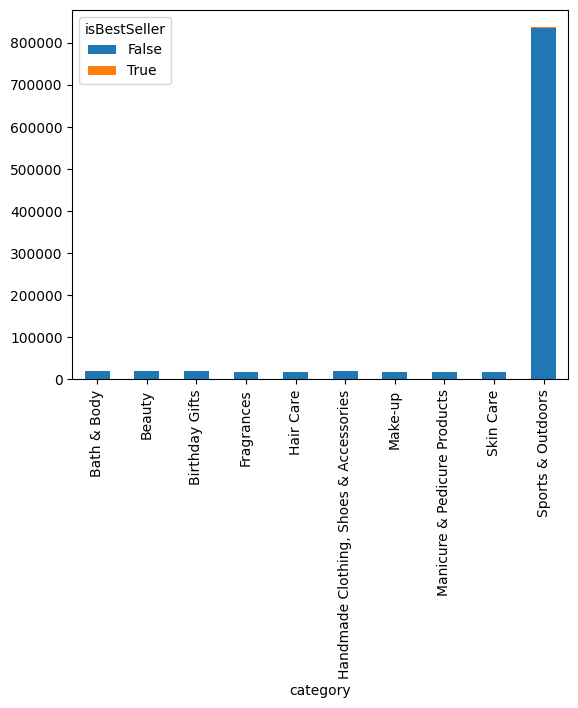

In [19]:
filtered_crosstab.plot(kind="bar", stacked=True)

In [23]:
#Part 2: Exploring Product Prices and Ratings Across Categories and Brands
#0. Preliminary Step: Remove outliers in product prices.Porque hay productos extremadamente caros que distorsionan medias, graficos y correlaciones. 
#Calcular interquartil: IQR = Q3 - Q1
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

Q1, Q3, IQR

(np.float64(9.99), np.float64(45.99), np.float64(36.0))

In [24]:
#Vamos a calcular los limites, todo producto por debajo de lower_limit y por encima de upper_limit sera considerado outlier
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

lower_limit, upper_limit

(np.float64(-44.01), np.float64(99.99000000000001))

In [26]:
df_part_2 = df[(df["price"] >= lower_limit) & (df["price"] <= upper_limit)]
df_part_2

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers
...,...,...,...,...,...,...,...,...,...
2443646,2828589,B0CHSD7P2Q,"Motorbike Armour, Motorbike Clothing, Cycling ...",0.0,0,22.34,False,0,Motorbike Clothing
2443647,2828590,B0B7B8FNBQ,PROFIRST Waterproof Motorcycle 2 Piece Ladies ...,0.0,0,97.99,False,0,Motorbike Clothing
2443648,2828591,B0BD5FL5FB,Men’s Motorcycle Motorbike Biker Trousers Kevl...,0.0,0,52.99,False,0,Motorbike Clothing
2443649,2828592,B008OYLL4I,Texpeed Mens Motorcycle Motorbike Biker Trouse...,4.3,404,79.99,False,0,Motorbike Clothing


In [44]:
#Violin Plots
import seaborn as sns
import matplotlib.pyplot as plt

In [47]:
#Vamos a filtar por los top 20 categorias, porque tenemos muchas categorias 
top_20_categories = (df_part_2["category"].value_counts().head(20).index)
filtered_df = df_part_2[df_part_2["category"].isin(top_20_categories)]

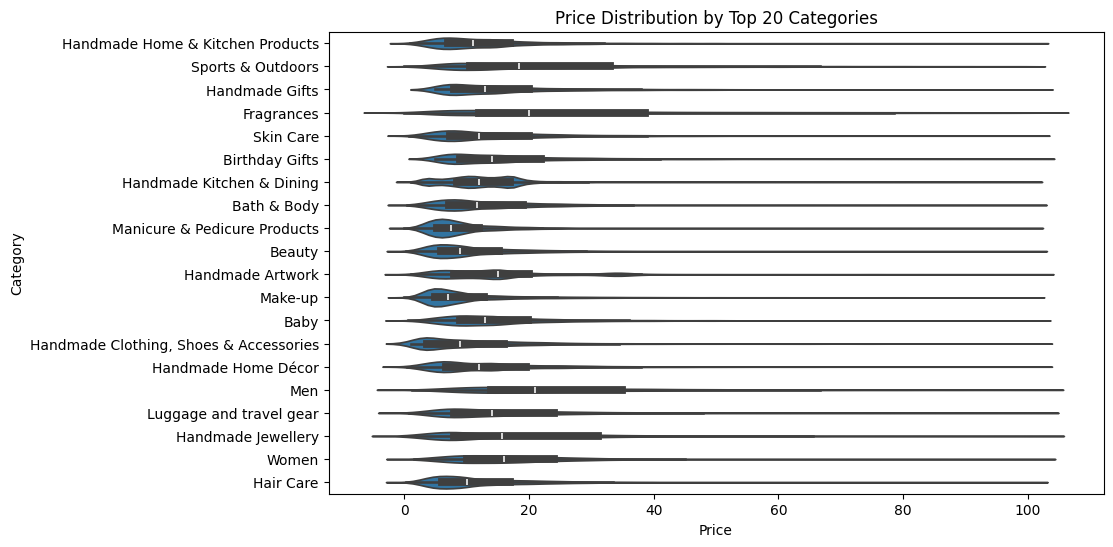

In [49]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=filtered_df,
    y="category",
    x="price"
)

plt.title("Price Distribution by Top 20 Categories")
plt.xlabel("Price")
plt.ylabel("Category")

plt.show()

In [ ]:
#Which product category commands the highest average price? 
#Sports & Outdoors appears to have the highest median price among the top categories.

In [55]:
#Box plots
top_10_categories = (df_part_2["category"].value_counts().head(10).index)
filtered_df = df_part_2[df_part_2["category"].isin(top_10_categories)]

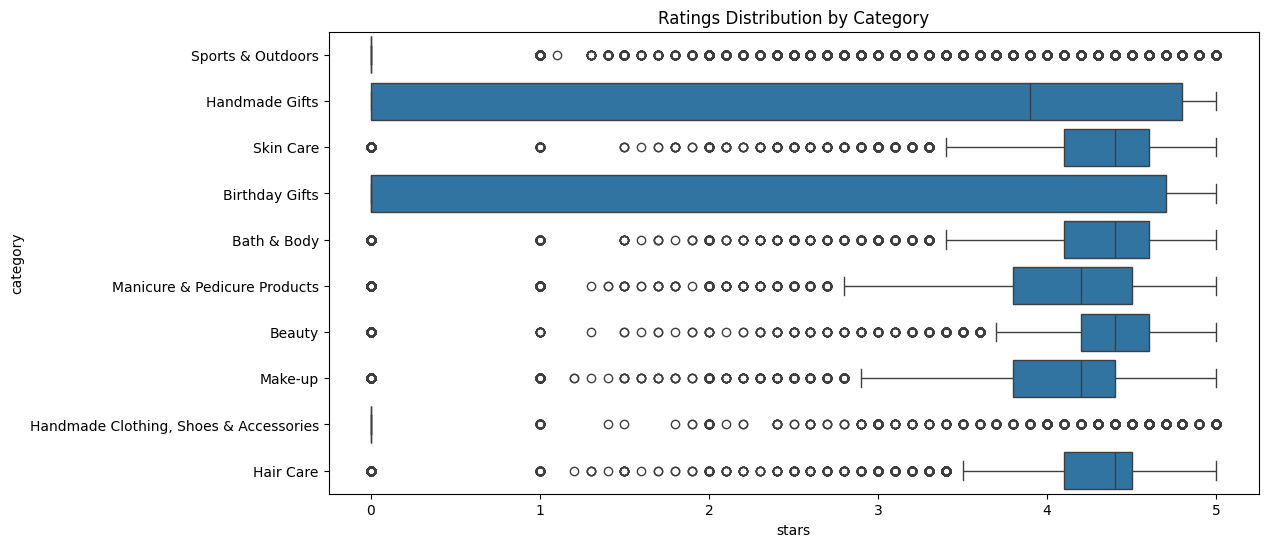

In [56]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=filtered_df,
    y="category",
    x="stars"
)

plt.title("Ratings Distribution by Category")

plt.show()

In [ ]:
#Which category tends to receive the highest median rating from customers? Don't filter here by top categories.
df_part_2.groupby("category")["stars"].median().sort_values(ascending=False)
#Computer Memory tends to receive the highest median customer rating, with a median rating of 4.7 stars.

category
Computer Memory                                 4.7
Beer, Wine & Spirits                            4.6
Building & Construction Toys                    4.6
Office Paper Products                           4.6
Kids' Play Figures                              4.6
                                               ... 
Synthesisers, Samplers & Digital Instruments    0.0
Tablets                                         0.0
Action Cameras                                  0.0
3D Printing & Scanning                          0.0
eBook Readers & Accessories                     0.0
Name: stars, Length: 296, dtype: float64

In [58]:
#Part 3: Investigating the Interplay Between Product Prices and Ratings
#Correlation coefficients:
correlation = df_part_2["price"].corr(df_part_2["stars"])

correlation

np.float64(-0.07767299878181444)

In [ ]:
#Existe una correlación negativa muy débil entre precio y rating.

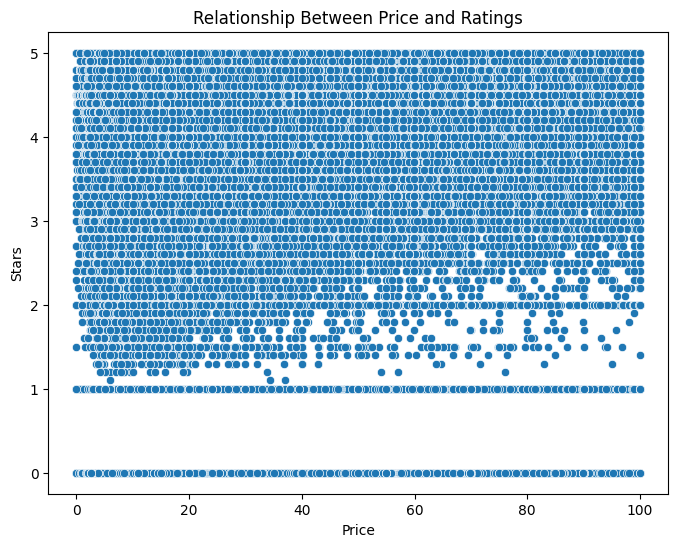

In [59]:
#Visualizations
#Scatter plot
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_part_2,
    x="price",
    y="stars"
)

plt.title("Relationship Between Price and Ratings")

plt.xlabel("Price")
plt.ylabel("Stars")

plt.show()


In [ ]:
#The scatter plot does not show a clear relationship between product price and customer ratings.
Ratings remain widely distributed across all price ranges, which supports the very weak correlation coefficient previously observed.

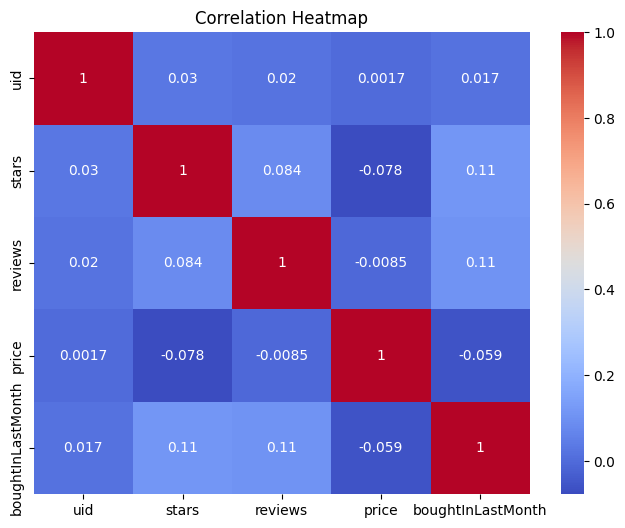

In [60]:
#Correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df_part_2.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [61]:
#QQ plot
import scipy.stats as stats

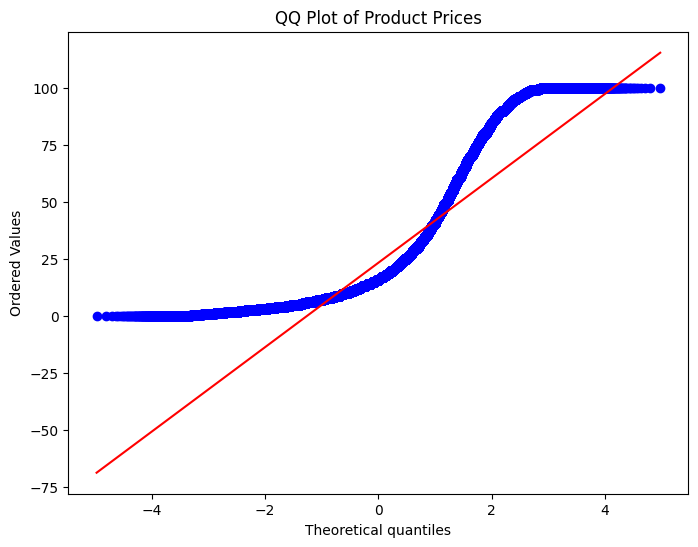

In [62]:
plt.figure(figsize=(8,6))

stats.probplot(df_part_2["price"], dist="norm", plot=plt)

plt.title("QQ Plot of Product Prices")

plt.show()

In [ ]:
#The QQ plot shows strong deviations from the reference line, indicating that product prices are not normally distributed.